# Foundations and Neural Network basics


## Machine Learning recap: why is it necessary and how we evaluate learning.

Deep Learning is a subcategory of Machine Learning, so we have to recapitulate some basic concepts for those who are not familiar with the field.

**Machine Learning**: the use and development of computer systems that are able to learn and adapt *without following explicit instructions*, by using algorithms and statistical models to analyse and draw inferences from patterns in data.

**Generalization**: model's ability to accurately predict or perform on new, unseen data, rather than just memorizing the training data.

In [ ]:
# @title
from IPython.display import Image, display

url = "https://framerusercontent.com/images/tx32puqCzYlG832gHMhinF3VkJU.png?scale-down-to=512&width=1132&height=1132"
display(Image(url=url, width=500))


Very basically put, they find patterns in the data to perform a task. There are several paradigms, but we will focus on one of them.

**Supervised learning**: the algorithm learns to map input data to a specific output based on example *input-output* pairs. The process involves training a statistical model using *labeled data*, meaning each sample is provided with the correct output in the training process.

### How do we train? How do we evaluate that the model has actually learnt?

With data. We divide the data in two sets:

**Training set**: the data that will be used to train the model. This is the data the model sees, the data it uses to learn to match the input with the desired output. We cannot use this data for evaluation because the model has already seen it. It usually amounts 60-80% of the available data.

**Test set**: we keep this data apart until the training phase is done. We do not show it to the model. When training is finished, we predict with it on the test set and we compare the predictions with the ground-truth (real output). It usually amounts to 10-20% of the available data.

In the cases where we are evaluating more than one model, including the cases where the model architecture is the same but training hyperparameters may differ, we use an extra set:

**Validation set**: technically, it is a part of the training set. The model is not seeing these examples during training, but we use them to evaluate different training processes or even different model architectures. We cannot use the training set because some models are better at memorizing than others &mdash; they may seem to learn, but do not generalize &mdash; and we cannot use the test set because we would be optimizing the models or the training hyperparameters for it. It usually amounts to 10-20% of the available data.

In [ ]:
# @title
from IPython.display import Image, display

url = "https://algotrading101.com/learn/wp-content/uploads/2020/06/training-validation-test-data-set.png"
display(Image(url=url, width=500))

We will get into the gritty details on how this is handled in Deep Learning in the following session. Let's start with the theory.


## The Perceptron



In [ ]:
# @title
from IPython.display import Image, display

url = "https://media.geeksforgeeks.org/wp-content/uploads/20251209120638608023/bhu.webp"
display(Image(url=url, width=500))

This is a perceptron. It is designed based in a biological neuron, a very basic version of it. In a neuron, dendrites act as branches that receive signals from other neurons, and the axon carries signals away.

The perceptron has a similar structure with the following components:

- **Inputs**: the input data, with values `xn`
- **Weights**: each input value has an associated weight `wn`.
- **Bias** (does not appear in the image above): an extra term `b`
- **Activation function `f`**: determines whether and to what extend it should activate based on its input. For example, a Sigmoid function will clamp the weighted sum between the values 0 and 1.

In [ ]:
# @title
from IPython.display import Image, display

print("Example of Sigmoid function")
url = "https://miro.medium.com/0*D5do3xhv5ulF50w2.png"
display(Image(url=url, width=500))

Example of Sigmoid function


These four are combined to produce the output of the perceptron:

$$\hat{y} = f(\sum_{i=1}^{n} w_i x_i + b)$$

**Important note**: In its most basic form (and with a non-linear activation function), a perceptron in nothing more than a linear regressor with the goal of classifying samples. There is a linear combination in the weighted sum and a decision boundary with the activation function. Its goal is classification.


In [ ]:
# @title
from IPython.display import Image, display

url = "https://miro.medium.com/1*6ApG38C_7iiuIPP9bopdhQ.gif"
display(Image(url=url, width=500))

### The XOR problem

The XOR (Excluisve OR) logical operation outputs 1 when the inputs differ, and 0 when they are equal. If we try to classify those points with a perceptron, we run into the problem that the two classes (0 and 1 for the outputs) are not linearly separable:


In [ ]:
# @title
from IPython.display import Image, display

url = "https://media2.dev.to/dynamic/image/width=1280,height=720,fit=cover,gravity=auto,format=auto/https%3A%2F%2Fdev-to-uploads.s3.amazonaws.com%2Fi%2Flkli02223oqhlac1jetz.png"
display(Image(url=url, width=500))

A perceptron, or a single layer of perceptrons (translates to several straight lines in the 2D space), could not solve this problem.

## Multi-layer Perceptron (MLP)

The solution was to stack them in layers: the input layer, a hidden layer, and the output layer.

In [ ]:
# @title
from IPython.display import Image, display

url = "https://media.geeksforgeeks.org/wp-content/uploads/20250929154234052438/backpropagation_in_neural_network_8.webp"
display(Image(url=url, width=500))

The key is the hidden layer.

**Hidden layers create *internal representations* of the data by using the operations we have seen. This allows the model to identify intricate patterns that the input layer cannot interpret on its own**.

Thanks to them, the MLP can map inputs to outputs that are not linearly separable.

A few aspects to consider about hidden layers:

- We can stack them. The more we stack, the *deeper* the neural network is. The deeper we move through the network, the more abstract the input representations get. We will look at examples of this in the third session, by looking at different model architectures.
- **Universal Approximation Theorems (UATs)**: state that neural networks with a certain structure can, in principle, approximate any continuous function to any desired degree of accuracy.

We now know how an MLP &mdash; the simplest type of neural network &mdash; can produce a desired output. But, how do we teach them to do it?



## What does 'training' mean? How does an MLP learn?

Training means nothing more than slowly tuning the weights (also called parameters) of the network. How do we do it?

In the gathered data, for every input we have the desired output by the model, also called *ground truth*. Let's suppose we are working with the simplest example possible: a linear regression. Our input is the X value, the output is the Y value, and we have a single weight and bias:

$$\hat{y} = w x + b$$

his means we have the simplest version of the Perceptron &mdash; no hidden layers and no activation function, just a weight and a bias &mdash; but it works to understand the training process.

When we start training, the weights are initialized randomly with small values. The output, therefore, is also random.

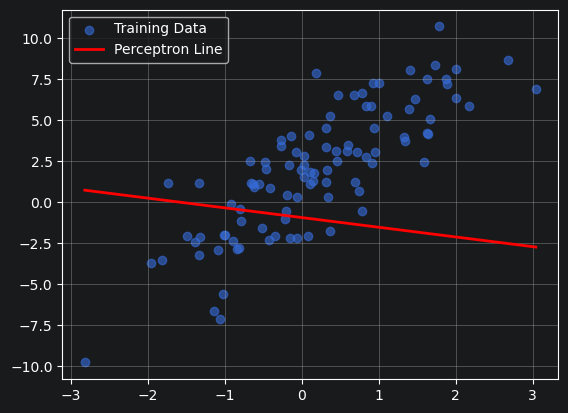

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Generate data (Standard normal distribution)
X_train = torch.randn(100, 1)
Y_train = 3 * X_train + 1 + torch.randn(100, 1) * 2

# Setup model
perceptron = nn.Linear(1, 1)

x_min = X_train.min().item()
x_max = X_train.max().item()
x = np.linspace(x_min, x_max, 100)

m = perceptron.weight.item()
b = perceptron.bias.item()
y = m * x + b

plt.scatter(X_train.numpy(), Y_train.numpy(), label="Training Data", alpha=0.6)
plt.plot(x, y, color='red', label="Perceptron Line", linewidth=2)
plt.legend()
plt.grid(True)
plt.show()

### The Loss Function

Now, we need a way to tell the model if what it is doing is right or wrong. For that, we define what we call a *loss function*: it considers the output of the model and the ground truth, and defines a difference between them. During training, the model will learn to minimize it.

For our simple case, we can define it as a Mean Squared Error (MSE), to fit the line to our data:

$$Loss (MSE) = \frac{1}{n} \sum_{i=1}^{n}{(y_i - \hat{y}_i)}^2$$


In [2]:
# Pre-defined with PyTorch
loss_fn = nn.MSELoss()
y_pred = perceptron(X_train)
loss_fn(y_pred, Y_train).item()

28.224695205688477

We want to minimize this value. How do we do it?

### The training process: Gradient Descent

As stated before, the part of the network that is tuned are the weights. They are what make the output change, what makes the output closer to the ground truth. Since we want to minimize the loss, we can look at the derivative of the function; we can asume, in this case, it is a simple quadratic function.


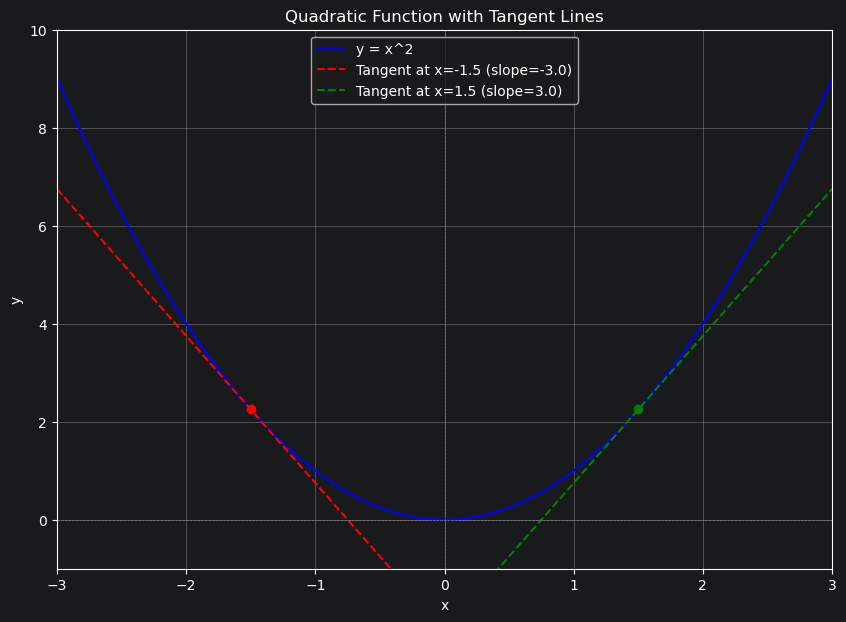

In [3]:
# @title
import matplotlib.pyplot as plt
import numpy as np

def quadratic_function(x):
    return x**2

def quadratic_derivative(x):
    return 2 * x

# Generate x values
x = np.linspace(-3, 3, 400)
y = quadratic_function(x)

# Choose points for tangents: one negative slope, one positive slope
x_tangent1 = -1.5 # Negative slope
x_tangent2 = 1.5  # Positive slope

y_tangent1 = quadratic_function(x_tangent1)
y_tangent2 = quadratic_function(x_tangent2)

# Calculate slopes at these points
slope1 = quadratic_derivative(x_tangent1)
slope2 = quadratic_derivative(x_tangent2)

# Calculate y-intercepts for tangent lines: y = mx + c => c = y - mx
c1 = y_tangent1 - slope1 * x_tangent1
c2 = y_tangent2 - slope2 * x_tangent2

# Generate points for tangent lines
y_line1 = slope1 * x + c1
y_line2 = slope2 * x + c2

# Plotting
plt.figure(figsize=(10, 7))
plt.plot(x, y, label='y = x^2', color='blue')

# Plot tangent 1
plt.plot(x, y_line1, label=f'Tangent at x={x_tangent1} (slope={slope1})', color='red', linestyle='--')
plt.scatter(x_tangent1, y_tangent1, color='red', zorder=5)

# Plot tangent 2
plt.plot(x, y_line2, label=f'Tangent at x={x_tangent2} (slope={slope2})', color='green', linestyle='--')
plt.scatter(x_tangent2, y_tangent2, color='green', zorder=5)

plt.title('Quadratic Function with Tangent Lines')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.ylim(min(y)-1, max(y)+1)
plt.xlim(min(x), max(x))
plt.show()

As we all know, we can use the derivative of the function to know the slope of the function at that point. If the slope is positive, the function is going up; if it is negative, the function is going down. So, with the following partial derivative:

$$\frac{\partial Loss}{\partial w}$$

We know if we should increase the value of the weight or diminish it. In this manner, we can establish a gradient descent for the weight, doing it step by step until it reaches a point where it does not change much after some time:

$$w_{i+1} = w_i - \eta\frac{\partial Loss}{\partial w} $$

For each iteration of training, we are moving our weights in the direction where they minimize the loss function.

#### What is $\eta$?

It is a hyperparameter called *learning rate*. It defines how much we move the weight in the desired direction. It has to be big enough so that at some point we reach the minima, but small enough to avoid getting out of the valley.

And with that, we have our method to perform the gradient descent and make the model learn:

In [ ]:
optimizer = torch.optim.SGD(perceptron.parameters(), lr=0.01)  # Define learning rate

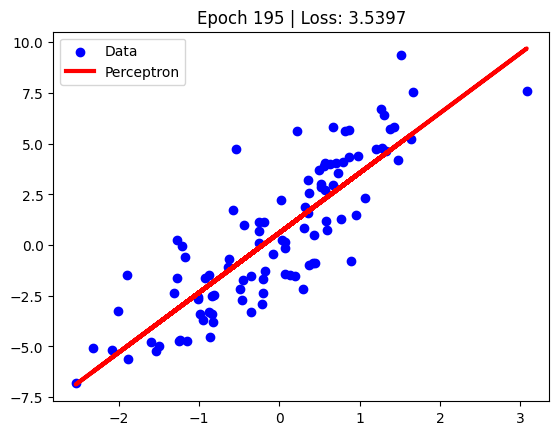

In [ ]:
from IPython.display import display, clear_output
import time

fig, ax = plt.subplots()

for epoch in range(200):
    predictions = perceptron(X_train)
    loss = loss_fn(predictions, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        clear_output(wait=True)

        ax.cla()
        ax.scatter(X_train.numpy(), Y_train.numpy(), color="blue", label="Data")
        ax.plot(X_train.numpy(), predictions.detach().numpy(), color="red", lw=3, label="Perceptron")
        ax.set_title(f"Epoch {epoch} | Loss: {loss.item():.4f}")
        ax.legend()

        display(fig)

        time.sleep(0.1)

plt.close()

This was a very simple example with a single perceptron. What happens when we work with an MLP?

## Backpropagation

Backpropagation is the algorithm that allows us to update the weights of the hidden layers. The algorithm is simple: it just uses the power of the *chain rule*. The loss depends on the output which depends on the weights of the final layer which depend on the weights of the previous layer...

To update the weights of a hidden layer $h_m$ we just have to apply the chain rule:

$$\frac{\partial L}{\partial w_{h_m}} = \frac{\partial L}{\partial \hat{y}} \frac{\partial \hat{y}}{\partial w_{h_n}} \frac{\partial w_{h_n}}{\partial w_{h_{n-1}}} ... \frac{\partial w_{h_{m+1}}}{\partial w_{h_m}}$$

That is what the piece of code `loss.backward()` does &mdash; PyTorch has that built in.